
=== REGULA FALSI ===
Akar: 1.5213695345376017
Iter  a          b          c          f(c)       error%    
-----------------------------------------------------------------
1     1.000000   2.000000   1.333333   -0.962963  0.000000  
2     1.333333   2.000000   1.462687   -0.333339  8.843537  
3     1.462687   2.000000   1.504019   -0.101818  2.748133  
4     1.504019   2.000000   1.516331   -0.029895  0.811931  
5     1.516331   2.000000   1.519919   -0.008675  0.236064  
6     1.519919   2.000000   1.520957   -0.002509  0.068308  
7     1.520957   2.000000   1.521258   -0.000725  0.019738  
8     1.521258   2.000000   1.521344   -0.000209  0.005701  
9     1.521344   2.000000   1.521370   -0.000060  0.001647  

=== BISECTION ===
Akar: 1.5213797068045674
Iter  a          b          c          f(c)       error%    
-----------------------------------------------------------------
1     1.000000   2.000000   1.500000   -0.125000  0.000000  
2     1.500000   2.000000   1.750000   1.6093

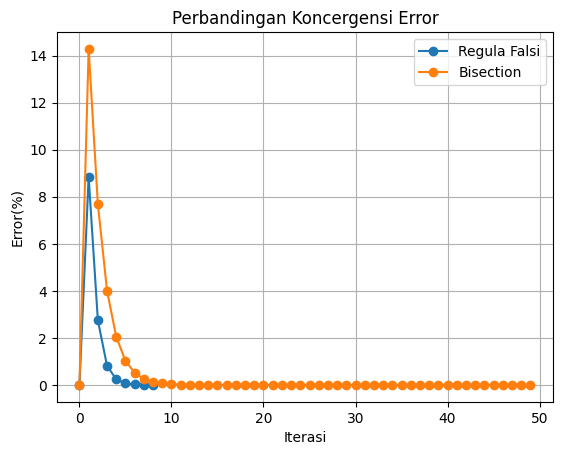

In [3]:
from error_library.regula_falsi import RegulaFalsi
from error_library.bisection import Bisection
import matplotlib.pyplot as plt

# =========================
# INPUT USER
# =========================
fungsi_input = input("Masukkan fungsi f(x): ")
a = float(input("Masukkan batas bawah (a): "))
b = float(input("Masukkan batas atas (b): "))
tol = float(input("Masukkan toleransi: "))
max_iter = int(input("Masukkan maksimum iterasi: "))

def f(x):
    return eval(fungsi_input)

# =========================
# VALIDASI
# =========================
try:
    f(1)
except:
    print("Fungsi tidak valid! Gunakan x**2 bukan x^2")
    exit()

if f(a) * f(b) > 0:
    print("Interval tidak valid!")
    exit()

# =========================
# REGULA FALSI
# =========================
rf = RegulaFalsi(f, a, b, tol, max_iter)
akar_rf = rf.solve()

print("\n=== REGULA FALSI ===")
print("Akar:", akar_rf)

print(f"{'Iter':<5} {'a':<10} {'b':<10} {'c':<10} {'f(c)':<10} {'error%':<10}")
print("-"*65)

for data in rf.get_iterations():
    print(f"{data['iterasi']:<5} "
          f"{data['a']:<10.6f} "
          f"{data['b']:<10.6f} "
          f"{data['c']:<10.6f} "
          f"{data['fc']:<10.6f} "
          f"{data['error']:<10.6f}")

# =========================
# BISECTION
# =========================
bs = Bisection(f, a, b, tol, max_iter)
akar_bs = bs.solve()

print("\n=== BISECTION ===")
print("Akar:", akar_bs)

print(f"{'Iter':<5} {'a':<10} {'b':<10} {'c':<10} {'f(c)':<10} {'error%':<10}")
print("-"*65)

for data in bs.get_iterations():
    print(f"{data['iterasi']:<5} "
          f"{data['a']:<10.6f} "
          f"{data['b']:<10.6f} "
          f"{data['c']:<10.6f} "
          f"{data['fc']:<10.6f} "
          f"{data['error']:<10.6f}")

# =========================
# GRAFIK KONVERGENSI
# =========================
rf_errors = [data['error'] for data in rf.get_iterations()]
bs_errors = [data['error'] for data in bs.get_iterations()]

plt.figure()

plt.plot(rf_errors, marker='o', label='Regula Falsi')
plt.plot(bs_errors, marker='o', label='Bisection')

plt.xlabel("Iterasi")
plt.ylabel("Error(%)")
plt.title("Perbandingan Koncergensi Error")

plt.legend()
plt.grid()

plt.show()